# The Drawdown You Were Promised 🤞
### A risk model that knows the mean and the volatility claims to know how far you can fall. We checked the promise against 90 years of tape.

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

Ask a risk system "how bad can a year get?" and, if it believes returns are a random walk with a
known average and a known volatility, it can answer exactly — there is a formula. This notebook
writes that answer down **before** each year, using only what was known at the time, and then
looks at what the year actually did.

> 📓 **This is the plain-language layer.** Binomial tests, the overlapping-window
> bootstrap, the era splits and the synthetic calibration are in
> **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
warnings.filterwarnings("ignore")
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from promised import data, strategy as st
print("real tapes available:", data.have_real(), "| as-of", data.AS_OF)

real tapes available: True | as-of 2022-11-30


## The answer first 🎯

| Question | Answer |
|---|---|
| Is the "how bad can it get" number right? | No. The 95% worst case was beaten in **16%** of years, not 5%. |
| Is it too gloomy or too cheerful? | Both: ordinary years are *calmer* than promised, bad years *much worse*. |
| Is the maths broken? | No — it is calibrated on a computer-made random walk. The market is not one. |
| Can you just multiply it by a safety factor? | The factor you'd need drifted from 1.03× to 1.92× depending on market and era. |
| Does a fancier model fix it? | Not reliably. Assuming *zero* average return helped more than modelling fat tails. |

**Signal: Real** · **Tradability: Mirage** — Fed the trailing mean and volatility, the Gaussian drawdown promise was broken in 16% of years instead of 5% — knowing mu and sigma is not knowing drawdown risk — and no fixed multiplier (it wandered from 1.0× to 1.9×) and no off-the-shelf model repairs it.

## 1 · The claim

If prices wander like a random walk with a steady drift and a steady volatility, the largest
peak-to-trough fall over a year has a known distribution — worked out exactly by Magdon-Ismail,
Atiya, Pratap and Abu-Mostafa in 2004. Risk teams use it to set drawdown budgets ("we can
tolerate a 25% fall"), and the Calmar ratio is often normalised by it. The promise, at full
strength: **know the mean and the volatility, and you know the drawdown risk.**

Here is what that promise looks like for the S&P 500, using its own long-run average and
volatility:

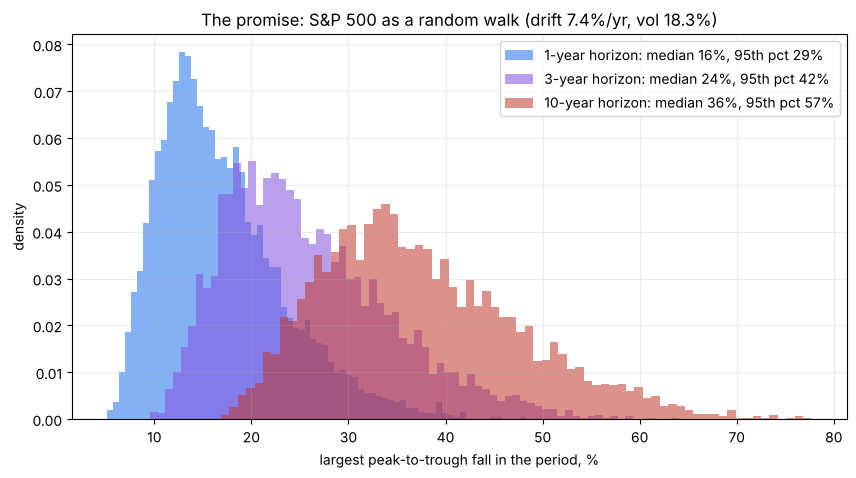

In [2]:
sp = data.load_sp500()
mu, sd = sp.mean(), sp.std()
fig, ax = plt.subplots(figsize=(10, 5))
for H, c in ((1, "#1f6feb"), (3, "#8250df"), (10, "#c0392b")):
    m = st.gbm_mdd(mu, sd, 252 * H, 4000)
    ax.hist(m * 100, bins=70, alpha=0.55, color=c, density=True,
            label=f"{H}-year horizon: median {np.median(m):.0%}, 95th pct {np.quantile(m, .95):.0%}")
ax.set_xlabel("largest peak-to-trough fall in the period, %"); ax.set_ylabel("density")
ax.set_title(f"The promise: S&P 500 as a random walk (drift {mu*252:.1%}/yr, vol {sd*np.sqrt(252):.1%})")
ax.legend(); plt.show()

## 2 · So what?

A drawdown budget is the number a pension board, a fund's investors or a trader's risk manager
signs off on. If the "95% worst case" is breached once in twenty years, everyone planned for it.
If it is breached one year in six, the plan is fiction — and the breach comes precisely in the
year capital is most expensive to raise.

## 3 · How we'd know

Before every calendar year, take only the **previous five years** of daily data, estimate the
average and the volatility, and write down the promised range of falls for the year ahead. Then
check: was the year's actual fall worse than the promised **95% worst case**? If the model is
right, that should happen in about **1 year in 20**. We do it on three market tapes — the S&P
500 (1995–2021), the Nasdaq (2004–2018) and the whole US stock market from Fama and French
(1937–2017, monthly) — and on twenty big individual stocks.

**What would make us say "the promise holds":** a breach rate statistically indistinguishable
from 5%. One detail first: how often you *look* at prices changes the answer.

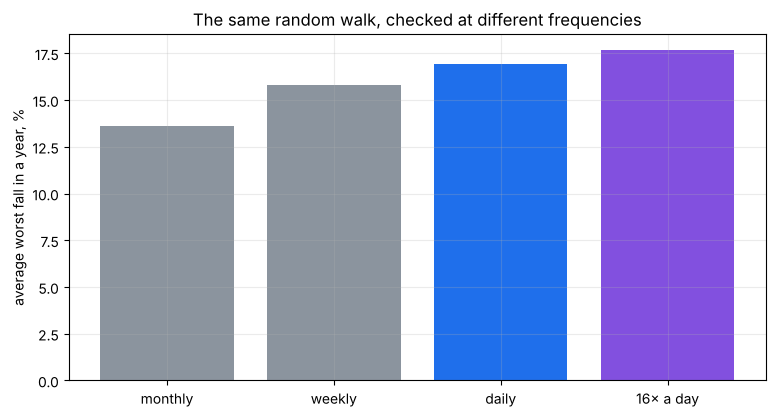

checking monthly hides 19% of the average daily-close drawdown


In [3]:
d = st.discretisation_table(0.0, 0.16, 1.0, steps_per_year=(12, 52, 252, 252 * 16), n_sims=3000)
fig, ax = plt.subplots(figsize=(9, 4.5))
lbl = ["monthly", "weekly", "daily", "16× a day"]
ax.bar(lbl, d["mean"] * 100, color=["#8b949e", "#8b949e", "#1f6feb", "#8250df"])
ax.set_ylabel("average worst fall in a year, %")
ax.set_title("The same random walk, checked at different frequencies")
plt.show()
print(f"checking monthly hides {1 - d['mean'].iloc[0] / d['mean'].iloc[2]:.0%} of the average daily-close drawdown")

The troughs between your observations don't show up in the drawdown. So the promise must be
computed at the same frequency the account is marked — daily for the indices, monthly for the
Fama-French series. Every number here does that.

## 4 · The teardown

### The S&P 500, one year at a time

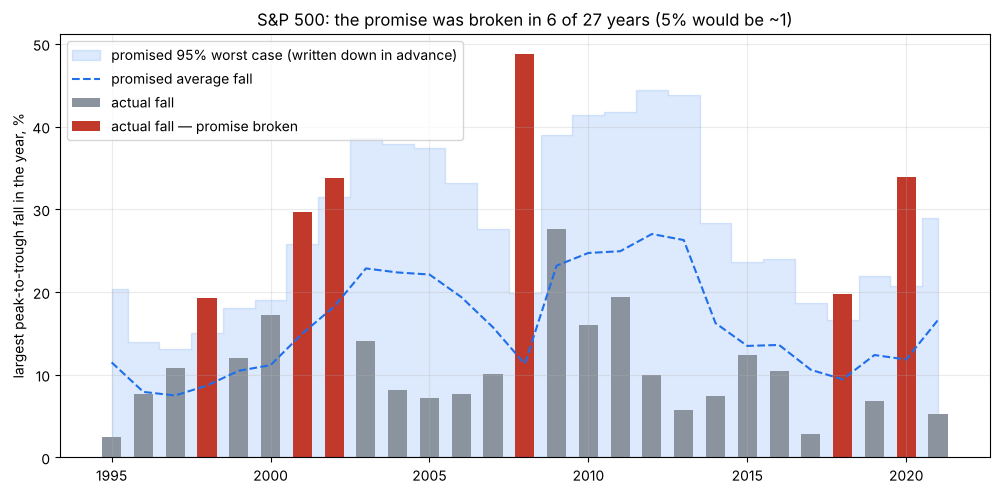

In [4]:
cov = st.coverage(sp, "sp500", 252, (1,), 5, ("gauss",), n_sims=4000)
fig, ax = plt.subplots(figsize=(12, 5.5))
x = cov["start"].to_numpy()
ax.fill_between(x, 0, cov["p_q95"] * 100, color="#1f6feb", alpha=0.15, step="mid",
                label="promised 95% worst case (written down in advance)")
ax.plot(x, cov["p_mean"] * 100, "--", color="#1f6feb", label="promised average fall")
br = cov["breach95"].to_numpy()
ax.bar(x[~br], cov["realised"][~br] * 100, width=0.6, color="#8b949e", label="actual fall")
ax.bar(x[br], cov["realised"][br] * 100, width=0.6, color="#c0392b", label="actual fall — promise broken")
ax.set_ylabel("largest peak-to-trough fall in the year, %"); ax.legend(loc="upper left")
ax.set_title(f"S&P 500: the promise was broken in {br.sum()} of {len(br)} years (5% would be ~1)")
plt.show()

Look at *when* the red bars come: 1998, 2001, 2002, 2008, 2018, 2020. Most follow a stretch of
calm, rising markets, so the trailing five years said "low volatility, high average return" — and the
promise was at its most optimistic exactly when it was about to be tested. In between, the grey
bars sit well **below** the dashed line: in the median year the market fell only
**0.68×** the promised average. The promise is too gloomy most of the time and far
too cheerful when it matters.

### Across all three tapes

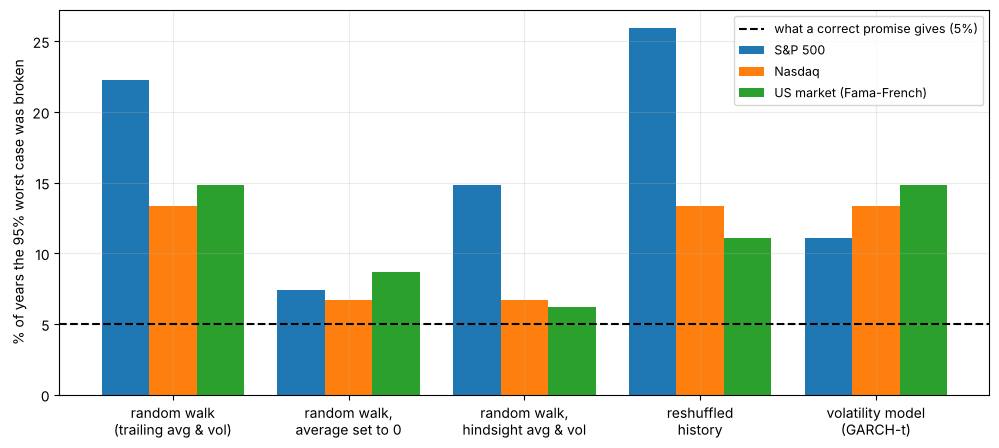

In [5]:
tapes = {t: data.load_tape(t) for t in data.INDEX_TAPES}
LB = {"sp500": 5, "nasdaq": 5, "ff_market": 10}
rows = []
for t, r in tapes.items():
    c = st.coverage(r, t, data.PERIODS_PER_YEAR[t], (1,), LB[t],
                    ("gauss", "gauss_mu0", "gauss_oracle", "boot", "garch_t"), n_sims=2000)
    rows.append(c)
one = pd.concat(rows, ignore_index=True)
rate = one.pivot_table(index="tape", columns="model", values="breach95", aggfunc="mean")
names = {"gauss": "random walk\n(trailing avg & vol)", "gauss_mu0": "random walk,\naverage set to 0",
         "gauss_oracle": "random walk,\nhindsight avg & vol", "boot": "reshuffled\nhistory",
         "garch_t": "volatility model\n(GARCH-t)"}
fig, ax = plt.subplots(figsize=(12, 5))
w = 0.27
for i, t in enumerate(data.INDEX_TAPES):
    ax.bar(np.arange(5) + (i - 1) * w, rate.loc[t, list(names)] * 100, width=w,
           label={"sp500": "S&P 500", "nasdaq": "Nasdaq", "ff_market": "US market (Fama-French)"}[t])
ax.axhline(5, color="k", ls="--", lw=1.5, label="what a correct promise gives (5%)")
ax.set_xticks(range(5)); ax.set_xticklabels(list(names.values()))
ax.set_ylabel("% of years the 95% worst case was broken"); ax.legend(fontsize=9)
plt.show()

The plain random walk breaks its promise far too often everywhere. Two things that sound like
they should fix it don't, reliably: reshuffling the last five years of real returns (it just
replays the calm), and a volatility model that knows today's turbulence (it doesn't know next
year's). What helped most was the boring move — **assume the average return is zero**: the
trailing average is what makes the promise most cheerful right before a fall.

> 🔬 **For the quants.** Exact binomial p-values on non-overlapping windows: S&P 500
> 0.002, Nasdaq 0.171, Fama-French 0.001. Overlapping 3/5/10-year windows
> with a moving-block bootstrap and the era-by-era multipliers are in notebook 02.

## 5 · The verdict

**Signal: Real.** Written down from the preceding years only, the Gaussian 95% drawdown band was breached in 1-year non-overlapping windows on the S&P 500 **22%** (6/27, p = 0.002), the Nasdaq **13%** (2/15, p = 0.171) and the Fama-French market **15%** (12/81, p = 0.001) — against a promised 5%, and **16%** pooled. The machinery is calibrated where it should be (5.8% on an i.i.d. Gaussian tape), so the failure belongs to the tape: the median year delivered only **0.68×** the promised mean drawdown, yet the bad years overran the 95th percentile 3.3× as often as promised. Even with the whole tape's mu and sigma in hindsight the S&P 500 band broke in 15% of years. Twenty survivor stocks — a floor — broke it in 12% of stock-years.

**Tradability: Mirage.** Scaling the Gaussian takes **k95 = 1.63×** pooled, but the multiplier a risk manager would have needed wanders from 1.03 to 1.92 across tapes and eras (max/min 1.87, outside the pre-registered 1.5). Neither the block bootstrap (15%) nor GARCH-t (14%) restored coverage on all three tapes. The cheapest partial repair was a humbler mean — drift set to zero, 8% pooled, k95 1.19 — at the price of over-promising at 5–10 years. No return stream, so Investable is not on offer.

## 6 · Could you use it?

The tempting fix is a safety factor: "take the textbook number and multiply by 1.5".

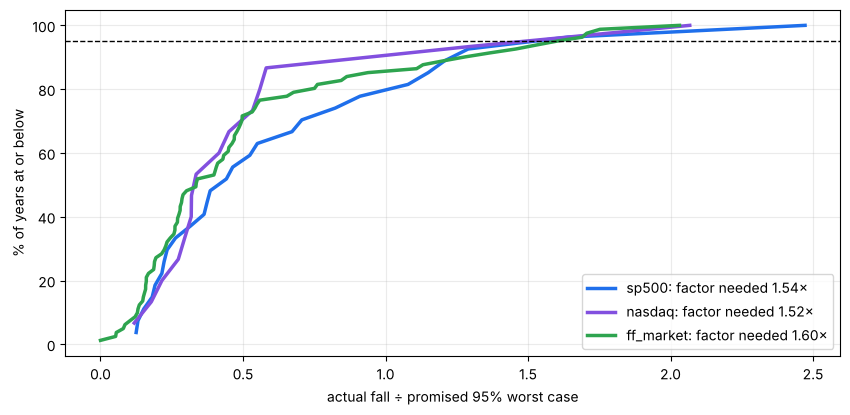

In [6]:
g = one[one["model"] == "gauss"].copy()
fig, ax = plt.subplots(figsize=(10, 4.5))
for t, c in zip(data.INDEX_TAPES, ("#1f6feb", "#8250df", "#2ea44f")):
    gt = g[g["tape"] == t]
    ratio = np.sort((gt["realised"] / gt["p_q95"]).to_numpy())
    ax.plot(ratio, np.arange(1, len(ratio) + 1) / len(ratio) * 100, lw=2.5, color=c,
            label=f"{t}: factor needed {st.multiplier(gt['realised'], gt['p_q95']):.2f}×")
ax.axhline(95, color="k", ls="--", lw=1)
ax.set_xlabel("actual fall ÷ promised 95% worst case"); ax.set_ylabel("% of years at or below")
ax.legend(); plt.show()

Pooled, you would have needed about **1.63×**. But split by market and era and the
factor ran from **1.03×** to **1.92×** — set it in calm decades and the next
crisis blows through it. For single stocks (and these 20 are *survivors*, the ones that made it
to 2022) the promise broke in 12% of stock-years; GE broke it in
30% of its years. A drawdown budget built on mean and volatility alone is a
number to be stress-tested, not trusted.

## 7 · Going further 🚪

- **Drawdown is a path property, volatility is not.** Two years with the same volatility can
  have very different drawdowns, depending on whether the bad days arrive together. Any model
  that ignores that clustering under-promises.
- **Watch the average.** A trailing average return is most optimistic just before falls. A
  zero-drift promise is cruder and was better calibrated at one year here.
- **Fork it.** Try a regime-switching model, or implied volatility instead of trailing
  volatility, and see if *any* model hits 5% on all three tapes.